# Imports

In [2]:
import warnings
import gym_super_mario_bros
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
import matplotlib.pyplot as plt
import copy
from tqdm.notebook import tqdm, trange
from nes_py.wrappers import JoypadSpace
from gym_super_mario_bros.actions import SIMPLE_MOVEMENT
from gym_super_mario_bros.actions import RIGHT_ONLY
from gym.wrappers import GrayScaleObservation, ResizeObservation, FrameStack
from collections import deque


warnings.filterwarnings('ignore')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


# Creating Env and Custom Grey Scale

In [3]:
import gym
import numpy as np
from gym import spaces

class Grayscale(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        obs_shape = self.observation_space.shape[:2] 
        self.observation_space = spaces.Box(low=0, high=255, shape=obs_shape, dtype=np.uint8)

    def observation(self, obs):
        return (0.2989 * obs[:,:,0] + 0.5870 * obs[:,:,1] + 0.1140 * obs[:,:,2]).astype(np.uint8)


def make_env():
    env = gym_super_mario_bros.make('SuperMarioBros-v0', apply_api_compatibility=True, render_mode='rgb-array')
    env = JoypadSpace(env, SIMPLE_MOVEMENT)
    env = Grayscale(env)           
    env = ResizeObservation(env, shape=84)
    env = FrameStack(env, num_stack=4)
    return env

# Baseline: DQN + e-greedy

In [4]:
def customized_weights_init(m):
    # compute the gain
    gain = nn.init.calculate_gain('relu')
    # init the convolutional layer
    if isinstance(m, nn.Conv2d):
        # init the params using uniform
        nn.init.xavier_uniform_(m.weight, gain=gain)
        nn.init.constant_(m.bias, 0)
    # init the linear layer
    if isinstance(m, nn.Linear):
        # init the params using uniform
        nn.init.xavier_uniform_(m.weight, gain=gain)
        nn.init.constant_(m.bias, 0)

In [ ]:
# Implement CNN and FC
class DeepQNet(nn.Module):
    def __init__(self, input_shape, n_actions):
        super(DeepQNet, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU()
        )
        conv_out_size = self._get_conv_out(input_shape)
        self.fc = nn.Sequential(
            nn.Linear(conv_out_size, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions)
        )

    def _get_conv_out(self, shape):
        o = self.conv(torch.zeros(1, *shape))
        return int(np.prod(o.size()))

    def forward(self, x):
        x = x.float() / 255.0
        conv_out = self.conv(x).view(x.size()[0], -1)
        return self.fc(conv_out)

In [6]:
class ReplayBuffer(object):
    """ Implement the Replay Buffer as a class, which contains:
            - self._data_buffer (list): a list variable to store all transition tuples.
            - add: a function to add new transition tuple into the buffer
            - sample_batch: a function to sample a batch training data from the Replay Buffer
    """
    def __init__(self, buffer_size):
        """Args:
               buffer_size (int): size of the replay buffer
        """
        # total size of the replay buffer
        self.total_size = buffer_size

        # create a list to store the transitions
        self._data_buffer = []
        self._next_idx = 0

    def __len__(self):
        return len(self._data_buffer)

    def add(self, obs, act, reward, next_obs, done):
        # create a tuple
        trans = (obs, act, reward, next_obs, done)

        # interesting implementation
        if self._next_idx >= len(self._data_buffer):
            self._data_buffer.append(trans)
        else:
            self._data_buffer[self._next_idx] = trans

        # increase the index
        self._next_idx = (self._next_idx + 1) % self.total_size

    def _encode_sample(self, indices):
        """ Function to fetch the state, action, reward, next state, and done arrays.
        
            Args:
                indices (list): list contains the index of all sampled transition tuples.
        """
        # lists for transitions
        obs_list, actions_list, rewards_list, next_obs_list, dones_list = [], [], [], [], []

        # collect the data
        for idx in indices:
            # get the single transition
            data = self._data_buffer[idx]
            obs, act, reward, next_obs, d = data
            # store to the list
            obs_list.append(np.asarray(obs))
            actions_list.append(np.asarray(act))
            rewards_list.append(np.asarray(reward))
            next_obs_list.append(np.asarray(next_obs))
            dones_list.append(np.asarray(d))
        # return the sampled batch data as numpy arrays
        return np.array(obs_list), np.array(actions_list), np.array(rewards_list), np.array(next_obs_list), np.array(
            dones_list)

    def sample_batch(self, batch_size):
        """ Args:
                batch_size (int): size of the sampled batch data.
        """
        # sample indices with replaced
        indices = [np.random.randint(0, len(self._data_buffer)) for _ in range(batch_size)]
        return self._encode_sample(indices)

In [7]:
class LinearSchedule(object):
    """ This schedule returns the value linearly"""
    def __init__(self, start_value, end_value, duration):
        # start value
        self._start_value = start_value
        # end value
        self._end_value = end_value
        # time steps that value changes from the start value to the end value
        self._duration = duration
        # difference between the start value and the end value
        self._schedule_amount = end_value - start_value

    def get_value(self, time):
        # logic: if time > duration, use the end value, else use the scheduled value
        return self._start_value + self._schedule_amount * min(1.0, time * 1.0 / self._duration)

In [8]:
class DQNAgent(object):
    # initialize the agent
    def __init__(self,
                 params,
                 ):
        # save the parameters
        self.params = params

        # environment parameters
        self.action_dim = params['action_dim']
        self.obs_dim = params['observation_dim']

        # executable actions
        self.action_space = params['action_space']

        # create value network
        self.behavior_policy_net = DeepQNet(input_shape=(4, 84, 84), n_actions=params['action_dim'])

        # create target network
        self.target_policy_net   = DeepQNet(input_shape=(4, 84, 84), n_actions=params['action_dim'])

        # initialize target network with behavior network
        self.behavior_policy_net.apply(customized_weights_init)
        self.target_policy_net.load_state_dict(self.behavior_policy_net.state_dict())

        # send the agent to a specific device: cpu or gpu
        self.device = torch.device("cuda")
        self.behavior_policy_net.to(self.device)
        self.target_policy_net.to(self.device)

        # optimizer
        self.optimizer = torch.optim.Adam(self.behavior_policy_net.parameters(), lr=params['learning_rate'])

    # get action
    def get_action(self, obs, eps):
        if np.random.random() < eps:  # with probability eps, the agent selects a random action
            action = np.random.choice(self.action_space, 1)[0]
            return action
        else:  # with probability 1 - eps, the agent selects a greedy policy
            obs = self._arr_to_tensor(obs).squeeze(-1).unsqueeze(0) 
            with torch.no_grad():
                q_values = self.behavior_policy_net(obs)
                action = q_values.max(dim=1)[1].item()
            return self.action_space[int(action)]

    # update behavior policy
    def update_behavior_policy(self, batch_data):
        # convert batch data to tensor and put them on device
        batch_data_tensor = self._batch_to_tensor(batch_data)

        # get the transition data
        obs_tensor = batch_data_tensor['obs']
        actions_tensor = batch_data_tensor['action']
        next_obs_tensor = batch_data_tensor['next_obs']
        rewards_tensor = batch_data_tensor['reward']
        dones_tensor = batch_data_tensor['done']

        # compute the q value estimation using the behavior network
        q_val = self.behavior_policy_net(obs_tensor)
        q = q_val.gather(1, actions_tensor)

        # compute the TD target using the target network
        next_q = self.target_policy_net(next_obs_tensor)
        max_q =  next_q.max(dim=1)[0].view(-1, 1).detach() 
        target = rewards_tensor + self.params['gamma'] * (1 - dones_tensor) * max_q

        # compute the loss
        loss = nn.MSELoss()
        td_loss = loss(q, target)

        # minimize the loss
        self.optimizer.zero_grad()
        td_loss.backward()
        self.optimizer.step()

        return td_loss.item()

    # update update target policy
    def update_target_policy(self):
        # hard update
        self.target_policy_net = copy.deepcopy(self.behavior_policy_net)

    # auxiliary functions
    def _arr_to_tensor(self, arr):
        arr = np.array(arr)
        arr_tensor = torch.from_numpy(arr).float().to(self.device)
        return arr_tensor

    def _batch_to_tensor(self, batch_data):
        # store the tensor
        batch_data_tensor = {'obs': [], 'action': [], 'reward': [], 'next_obs': [], 'done': []}
        # get the numpy arrays
        obs_arr, action_arr, reward_arr, next_obs_arr, done_arr = batch_data
        # convert to tensors
        batch_data_tensor['obs'] = torch.tensor(obs_arr, dtype=torch.float32).squeeze(-1).to(self.device)
        batch_data_tensor['action'] = torch.tensor(action_arr).long().view(-1, 1).to(self.device)
        batch_data_tensor['reward'] = torch.tensor(reward_arr, dtype=torch.float32).view(-1, 1).to(self.device)
        batch_data_tensor['next_obs'] = torch.tensor(next_obs_arr, dtype=torch.float32).squeeze(-1).to(self.device)
        batch_data_tensor['done'] = torch.tensor(done_arr, dtype=torch.float32).view(-1, 1).to(self.device)

        return batch_data_tensor

In [9]:
def train_dqn_agent(env, params):
    # create the DQN agent
    my_agent = DQNAgent(params)

    # create the epsilon-greedy schedule
    my_schedule = LinearSchedule(start_value=params['epsilon_start_value'],
                                 end_value=params['epsilon_end_value'],
                                 duration=params['epsilon_duration'])

    # create the replay buffer
    replay_buffer = ReplayBuffer(params['replay_buffer_size'])

    # training variables
    episode_t = 0
    rewards = []
    train_returns = []
    train_loss = []
    loss = 0

    # reset the environment
    obs, _ = env.reset()

    # start training
    pbar = trange(params['total_training_time_step'])
    last_best_return = 0
    for t in pbar:
        # scheduled epsilon at time step t
        eps_t = my_schedule.get_value(t)
        # get one epsilon-greedy action
        action = my_agent.get_action(obs, eps_t)

        # step in the environment
        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated  

        # add to the buffer
        replay_buffer.add(np.array(obs), action, reward, np.array(next_obs), done)
        rewards.append(reward)

        # check termination
        if done:
            # compute the return
            G = 0
            for r in reversed(rewards):
                G = r + params['gamma'] * G

            if G > last_best_return:
                torch.save(my_agent.behavior_policy_net.state_dict(), f"./{params['model_name']}.pt")

            # store the return
            train_returns.append(G)
            np.save(f"{params['model_name']}_returns.npy", np.array(train_returns))
            np.save(f"{params['model_name']}_loss.npy", np.array(train_loss))
            episode_idx = len(train_returns)

            # print the information
            pbar.set_description(
                f"Ep={episode_idx} | "
                f"G={np.mean(train_returns[-10:]) if train_returns else 0:.2f} | "
                f"Eps={eps_t}"
            )

            # reset the environment
            episode_t, rewards = 0, []
            obs, _ = env.reset()
        else:
            # increment
            obs = next_obs
            episode_t += 1

        if t > params['start_training_step']:
            # update the behavior model
            if not np.mod(t, params['freq_update_behavior_policy']):
                batch = replay_buffer.sample_batch(params['batch_size'])
                loss = my_agent.update_behavior_policy(batch)
                train_loss.append(loss)


            # update the target model
            if not np.mod(t, params['freq_update_target_policy']):
                my_agent.update_target_policy()

    # save the results
    return train_returns, train_loss

In [10]:
def plot_curves(arr_list, legend_list, color_list, ylabel, fig_title):
    """
    Args:
        arr_list (list): list of results arrays to plot
        legend_list (list): list of legends corresponding to each result array
        color_list (list): list of color corresponding to each result array
        ylabel (string): label of the Y axis

        Note that, make sure the elements in the arr_list, legend_list and color_list are associated with each other correctly.
        Do not forget to change the ylabel for different plots.
    """
    # set the figure type
    fig, ax = plt.subplots(figsize=(12, 8))

    # PLEASE NOTE: Change the labels for different plots
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Episodes")

    # ploth results
    h_list = []
    for arr, legend, color in zip(arr_list, legend_list, color_list):
        # compute the standard error
        arr_err = arr.std(axis=0) / np.sqrt(arr.shape[0])
        # plot the mean
        h, = ax.plot(range(arr.shape[1]), arr.mean(axis=0), color=color, label=legend)
        # plot the confidence band
        arr_err *= 1.96
        ax.fill_between(range(arr.shape[1]), arr.mean(axis=0) - arr_err, arr.mean(axis=0) + arr_err, alpha=0.3,
                        color=color)
        # save the plot handle
        h_list.append(h)

    # plot legends
    ax.set_title(f"{fig_title}")
    ax.legend(handles=h_list)

    plt.show()

In [ ]:
if __name__ == '__main__':
    # set the random seed
    np.random.seed(1234)
    random.seed(1234)
    torch.manual_seed(1234)

    # create environment
    my_env = make_env()

    # create training parameters
    train_parameters = {
        'observation_dim': (4, 84, 84),
        'action_dim': my_env.action_space.n,
        'action_space': list(range(my_env.action_space.n)),
        'gamma': 0.99,

        'total_training_time_step': 2_000_000,

        'epsilon_start_value': 1.0,
        'epsilon_end_value': 0.01,
        'epsilon_duration': 1_000_000,

        'replay_buffer_size': 100_000,
        'start_training_step': 10_000,
        'freq_update_behavior_policy': 4,
        'freq_update_target_policy': 2000,

        'batch_size': 64,
        'learning_rate': 1e-4,

        'model_name': "mario_dqn_egreedy_1234"
    }

    # create experiment
    train_returns, train_loss = train_dqn_agent(my_env, train_parameters)

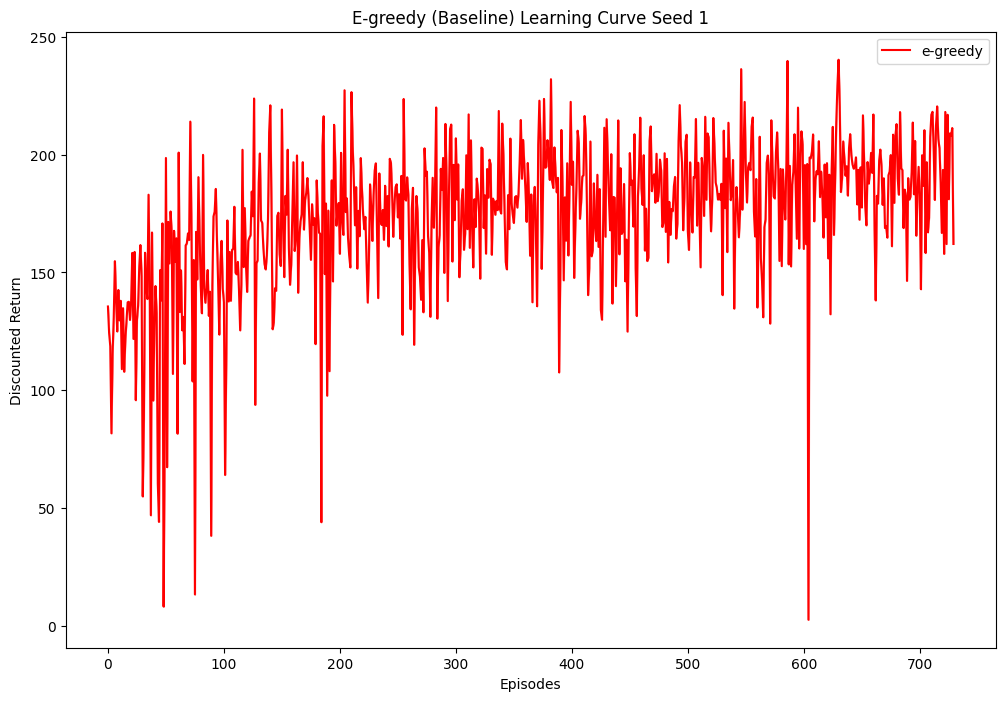

In [13]:
eg1 = np.load("data/mario_dqn_egreedy_1234_returns.npy")
eg_returns = np.array([eg1])

plot_curves(
    [eg_returns],
    ['e-greedy'],
    ['r'],
    'Discounted Return',
    'E-greedy (Baseline) Learning Curve Seed 1'
)

In [ ]:
if __name__ == '__main__':
    # set the random seed
    np.random.seed(5678)
    random.seed(5678)
    torch.manual_seed(5678)

    # create environment
    my_env = make_env()

    # create training parameters
    train_parameters = {
        'observation_dim': (4, 84, 84),
        'action_dim': my_env.action_space.n,
        'action_space': list(range(my_env.action_space.n)),
        'gamma': 0.99,

        'total_training_time_step': 2_000_000,

        'epsilon_start_value': 1.0,
        'epsilon_end_value': 0.01,
        'epsilon_duration': 1_000_000,

        'replay_buffer_size': 100_000,
        'start_training_step': 10_000,
        'freq_update_behavior_policy': 4,
        'freq_update_target_policy': 2000,

        'batch_size': 64,
        'learning_rate': 1e-4,

        'model_name': "mario_dqn_egreedy_5678"
    }

    # create experiment
    train_returns, train_loss = train_dqn_agent(my_env, train_parameters)

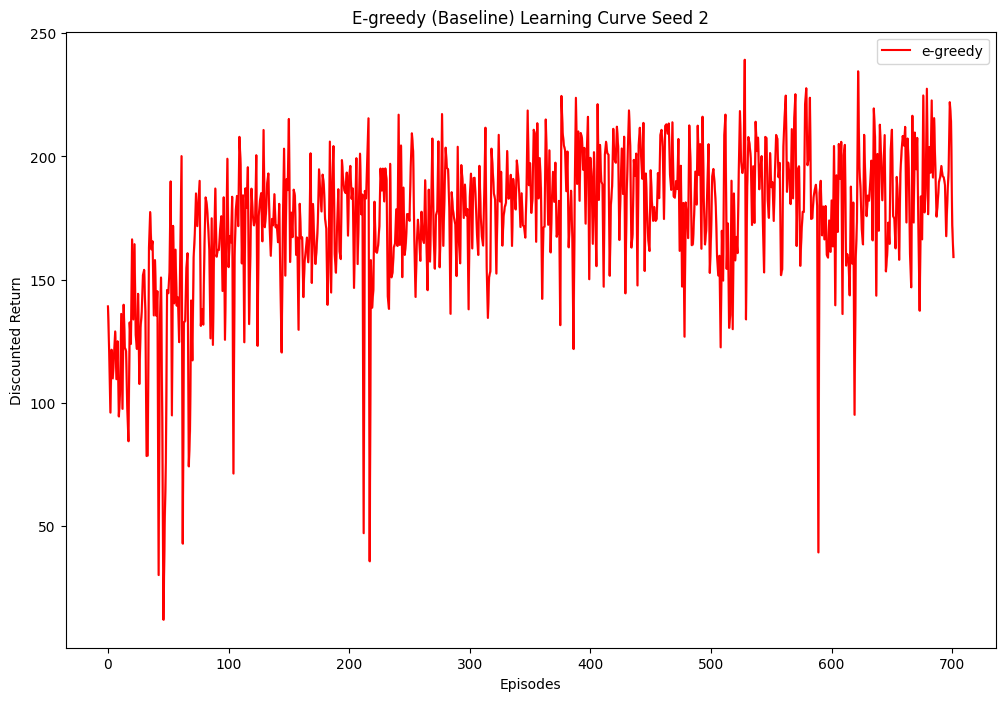

In [15]:
eg2 = np.load("data/mario_dqn_egreedy_5678_returns.npy")
eg_returns = np.array([eg2])

plot_curves(
    [eg_returns],
    ['e-greedy'],
    ['r'],
    'Discounted Return',
    'E-greedy (Baseline) Learning Curve Seed 2'
)

In [11]:
if __name__ == '__main__':
    # set the random seed
    np.random.seed(9012)
    random.seed(9012)
    torch.manual_seed(9012)

    # create environment
    my_env = make_env()

    # create training parameters
    train_parameters = {
        'observation_dim': (4, 84, 84),
        'action_dim': my_env.action_space.n,
        'action_space': list(range(my_env.action_space.n)),
        'gamma': 0.99,

        'total_training_time_step': 2_000_000,

        'epsilon_start_value': 1.0,
        'epsilon_end_value': 0.01,
        'epsilon_duration': 1_000_000,

        'replay_buffer_size': 100_000,
        'start_training_step': 10_000,
        'freq_update_behavior_policy': 4,
        'freq_update_target_policy': 2000,

        'batch_size': 64,
        'learning_rate': 1e-4,

        'model_name': "mario_dqn_egreedy_9012"
    }

    # create experiment
    train_returns, train_loss = train_dqn_agent(my_env, train_parameters)

  0%|          | 0/2000000 [00:00<?, ?it/s]

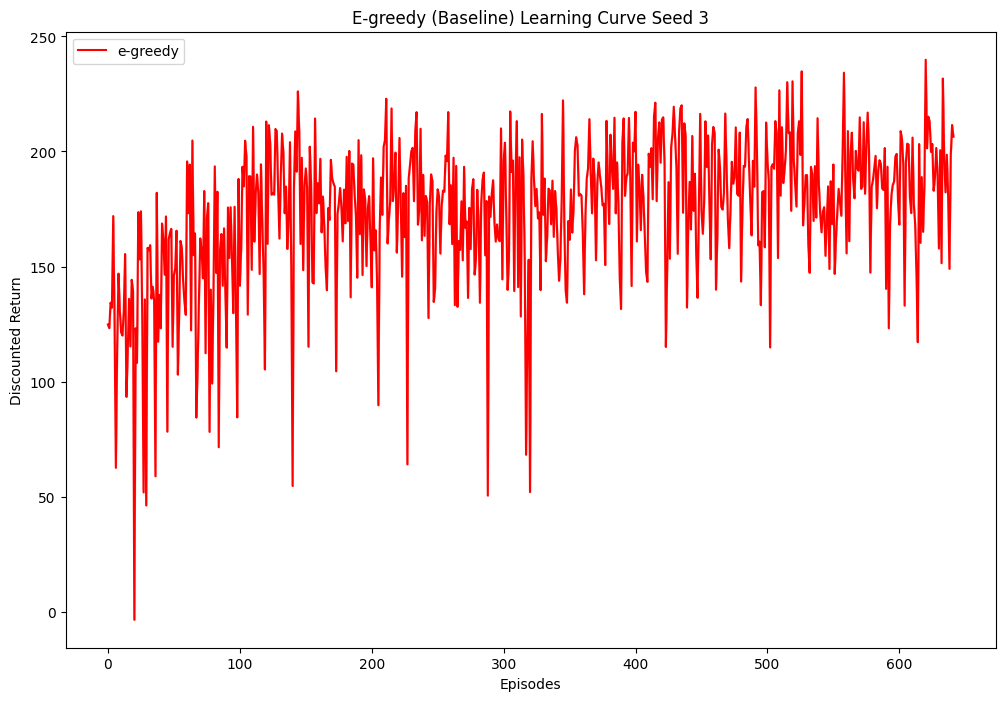

In [16]:
eg3 = np.load("data/mario_dqn_egreedy_9012_returns.npy")
eg_returns = np.array([eg3])

plot_curves(
    [eg_returns],
    ['e-greedy'],
    ['r'],
    'Discounted Return',
    'E-greedy (Baseline) Learning Curve Seed 3'
)

# Agent 2: DQN + SoftMax

In [20]:
class DQNAgent(object):
    # initialize the agent
    def __init__(self,
                 params,
                 ):
        # save the parameters
        self.params = params

        # environment parameters
        self.action_dim = params['action_dim']
        self.obs_dim = params['observation_dim']

        # executable actions
        self.action_space = params['action_space']

        # create value network
        self.behavior_policy_net = DeepQNet(input_shape=(4, 84, 84), n_actions=params['action_dim'])

        # create target network
        self.target_policy_net   = DeepQNet(input_shape=(4, 84, 84), n_actions=params['action_dim'])

        # initialize target network with behavior network
        self.behavior_policy_net.apply(customized_weights_init)
        self.target_policy_net.load_state_dict(self.behavior_policy_net.state_dict())

        # send the agent to a specific device: cpu or gpu
        self.device = torch.device("cuda")
        self.behavior_policy_net.to(self.device)
        self.target_policy_net.to(self.device)

        # optimizer
        self.optimizer = torch.optim.Adam(self.behavior_policy_net.parameters(), lr=params['learning_rate'])

    # get action
    def get_action(self, obs, tau):
        obs = self._arr_to_tensor(obs).squeeze(-1).unsqueeze(0)
        with torch.no_grad():
            q_values = self.behavior_policy_net(obs)
            # apply softmax with temperature tau
            probs = torch.softmax(q_values / tau, dim=1)
            # sample action from the probability distribution
            action = torch.multinomial(probs, 1).item()
        return self.action_space[int(action)]

    # update behavior policy
    def update_behavior_policy(self, batch_data):
        # convert batch data to tensor and put them on device
        batch_data_tensor = self._batch_to_tensor(batch_data)

        # get the transition data
        obs_tensor = batch_data_tensor['obs']
        actions_tensor = batch_data_tensor['action']
        next_obs_tensor = batch_data_tensor['next_obs']
        rewards_tensor = batch_data_tensor['reward']
        dones_tensor = batch_data_tensor['done']

        # compute the q value estimation using the behavior network
        q_val = self.behavior_policy_net(obs_tensor)
        q = q_val.gather(1, actions_tensor)

        # compute the TD target using the target network
        next_q = self.target_policy_net(next_obs_tensor)
        max_q =  next_q.max(dim=1)[0].view(-1, 1).detach() 
        target = rewards_tensor + self.params['gamma'] * (1 - dones_tensor) * max_q

        # compute the loss
        loss = nn.MSELoss()
        td_loss = loss(q, target)

        # minimize the loss
        self.optimizer.zero_grad()
        td_loss.backward()
        self.optimizer.step()

        return td_loss.item()

    # update update target policy
    def update_target_policy(self):
        # hard update
        self.target_policy_net = copy.deepcopy(self.behavior_policy_net)

    # auxiliary functions
    def _arr_to_tensor(self, arr):
        arr = np.array(arr)
        arr_tensor = torch.from_numpy(arr).float().to(self.device)
        return arr_tensor

    def _batch_to_tensor(self, batch_data):
        # store the tensor
        batch_data_tensor = {'obs': [], 'action': [], 'reward': [], 'next_obs': [], 'done': []}
        # get the numpy arrays
        obs_arr, action_arr, reward_arr, next_obs_arr, done_arr = batch_data
        # convert to tensors
        batch_data_tensor['obs'] = torch.tensor(obs_arr, dtype=torch.float32).squeeze(-1).to(self.device)
        batch_data_tensor['action'] = torch.tensor(action_arr).long().view(-1, 1).to(self.device)
        batch_data_tensor['reward'] = torch.tensor(reward_arr, dtype=torch.float32).view(-1, 1).to(self.device)
        batch_data_tensor['next_obs'] = torch.tensor(next_obs_arr, dtype=torch.float32).squeeze(-1).to(self.device)
        batch_data_tensor['done'] = torch.tensor(done_arr, dtype=torch.float32).view(-1, 1).to(self.device)

        return batch_data_tensor

In [21]:
def train_dqn_agent(env, params):
    # create the DQN agent
    my_agent = DQNAgent(params)

    # create the epsilon-greedy schedule
    my_schedule = LinearSchedule(start_value=params['epsilon_start_value'],
                                 end_value=params['epsilon_end_value'],
                                 duration=params['epsilon_duration'])

    # create the replay buffer
    replay_buffer = ReplayBuffer(params['replay_buffer_size'])

    # training variables
    episode_t = 0
    rewards = []
    train_returns = []
    train_loss = []
    loss = 0

    # reset the environment
    obs, _ = env.reset()

    # start training
    pbar = trange(params['total_training_time_step'])
    last_best_return = 0
    for t in pbar:
        # scheduled epsilon at time step t
        tau = my_schedule.get_value(t)
        # get one epsilon-greedy action
        action = my_agent.get_action(obs, tau)

        # step in the environment
        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated  

        # add to the buffer
        replay_buffer.add(np.array(obs), action, reward, np.array(next_obs), done)
        rewards.append(reward)

        # check termination
        if done:
            # compute the return
            G = 0
            for r in reversed(rewards):
                G = r + params['gamma'] * G

            if G > last_best_return:
                torch.save(my_agent.behavior_policy_net.state_dict(), f"./{params['model_name']}.pt")

            # store the return
            train_returns.append(G)
            np.save(f"{params['model_name']}_returns.npy", np.array(train_returns))
            np.save(f"{params['model_name']}_loss.npy", np.array(train_loss))
            episode_idx = len(train_returns)

            # print the information
            pbar.set_description(
                f"Ep={episode_idx} | "
                f"G={np.mean(train_returns[-10:]) if train_returns else 0:.2f} | "
                f"Eps={tau}"
            )

            # reset the environment
            episode_t, rewards = 0, []
            obs, _ = env.reset()
        else:
            # increment
            obs = next_obs
            episode_t += 1

        if t > params['start_training_step']:
            # update the behavior model
            if not np.mod(t, params['freq_update_behavior_policy']):
                batch = replay_buffer.sample_batch(params['batch_size'])
                loss = my_agent.update_behavior_policy(batch)
                train_loss.append(loss)


            # update the target model
            if not np.mod(t, params['freq_update_target_policy']):
                my_agent.update_target_policy()

    # save the results
    return train_returns, train_loss

In [21]:
if __name__ == '__main__':
    # set the random seed
    np.random.seed(1234)
    random.seed(1234)
    torch.manual_seed(1234)

    # create environment
    my_env = make_env()

    # create training parameters
    train_parameters = {
        'observation_dim': (4, 84, 84),
        'action_dim': my_env.action_space.n,
        'action_space': list(range(my_env.action_space.n)),
        'gamma': 0.99,

        'total_training_time_step': 2_000_000,

        'epsilon_start_value': 5.0,
        'epsilon_end_value': 0.1,
        'epsilon_duration': 1_000_000,

        'replay_buffer_size': 100_000,
        'start_training_step': 10_000,
        'freq_update_behavior_policy': 4,
        'freq_update_target_policy': 2000,

        'batch_size': 64,
        'learning_rate': 1e-4,

        'model_name': "mario_dqn_softmax_1234"
    }

    # create experiment
    train_returns, train_loss = train_dqn_agent(my_env, train_parameters)

  0%|          | 0/2000000 [00:00<?, ?it/s]

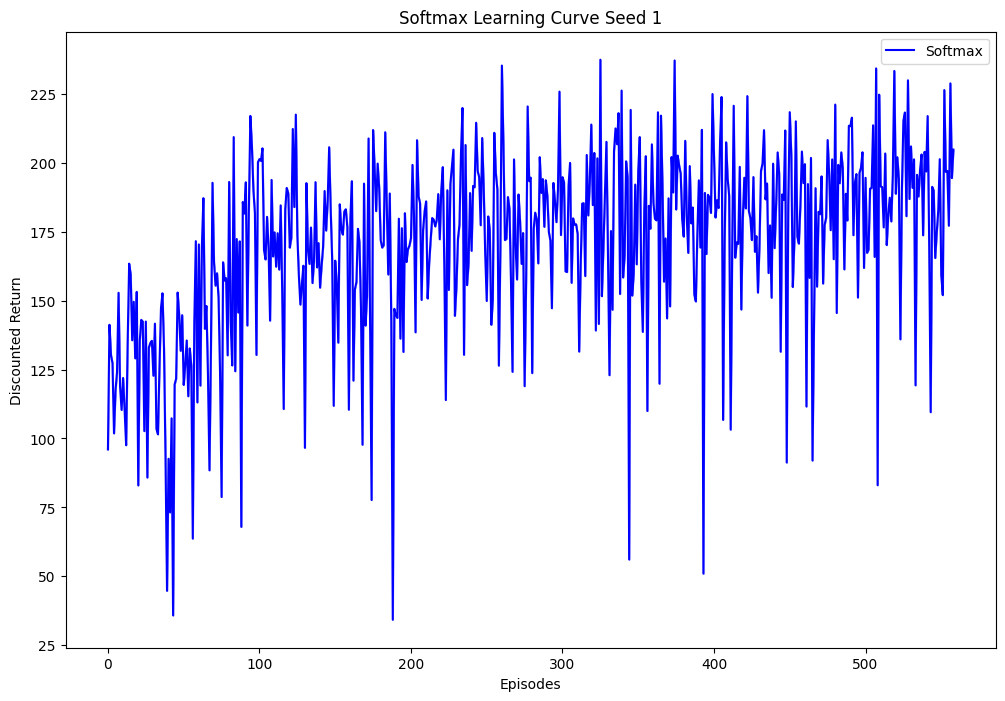

In [17]:
sm1 = np.load("data/mario_dqn_softmax_1234_returns.npy")
softmax_returns = np.array([sm1])

plot_curves(
    [softmax_returns],
    ['Softmax'],
    ['b'],
    'Discounted Return',
    'Softmax Learning Curve Seed 1'
)

In [24]:
if __name__ == '__main__':
    # set the random seed
    np.random.seed(5678)
    random.seed(5678)
    torch.manual_seed(5678)

    # create environment
    my_env = make_env()

    # create training parameters
    train_parameters = {
        'observation_dim': (4, 84, 84),
        'action_dim': my_env.action_space.n,
        'action_space': list(range(my_env.action_space.n)),
        'gamma': 0.99,

        'total_training_time_step': 2_000_000,

        'epsilon_start_value': 5.0,
        'epsilon_end_value': 0.1,
        'epsilon_duration': 1_000_000,

        'replay_buffer_size': 100_000,
        'start_training_step': 10_000,
        'freq_update_behavior_policy': 4,
        'freq_update_target_policy': 2000,

        'batch_size': 64,
        'learning_rate': 1e-4,

        'model_name': "mario_dqn_softmax_5678"
    }

    # create experiment
    train_returns, train_loss = train_dqn_agent(my_env, train_parameters)

  0%|          | 0/2000000 [00:00<?, ?it/s]

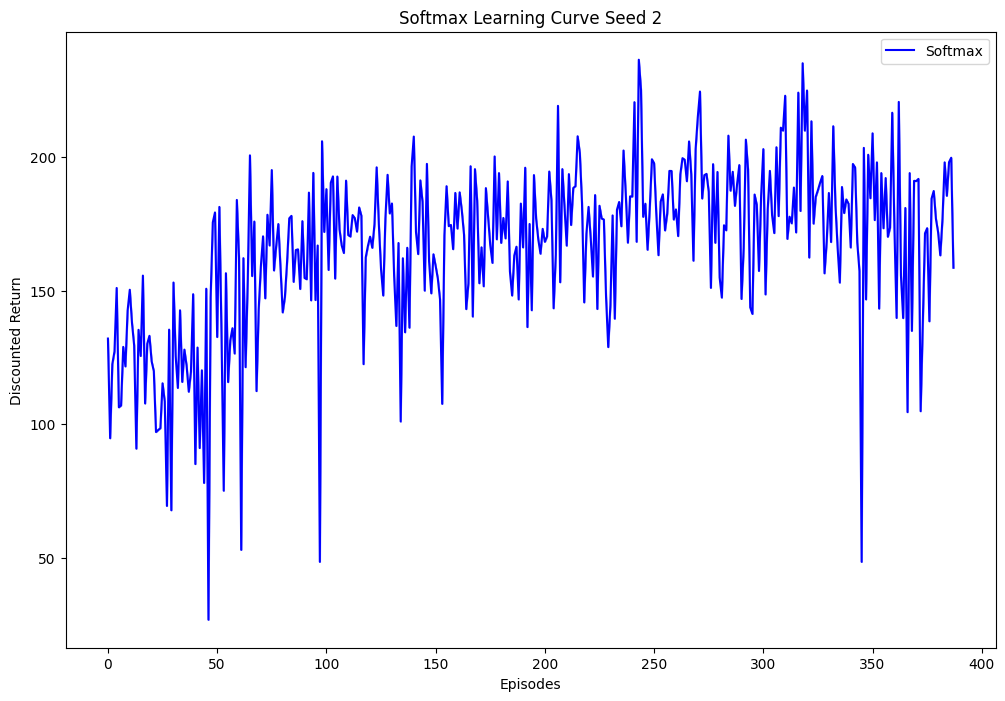

In [18]:
sm2 = np.load("data/mario_dqn_softmax_5678_returns.npy")
softmax_returns = np.array([sm2])

plot_curves(
    [softmax_returns],
    ['Softmax'],
    ['b'],
    'Discounted Return',
    'Softmax Learning Curve Seed 2'
)

In [ ]:
if __name__ == '__main__':
    # set the random seed
    np.random.seed(9012)
    random.seed(9012)
    torch.manual_seed(9012)

    # create environment
    my_env = make_env()

    # create training parameters
    train_parameters = {
        'observation_dim': (4, 84, 84),
        'action_dim': my_env.action_space.n,
        'action_space': list(range(my_env.action_space.n)),
        'gamma': 0.99,
        'total_training_time_step': 2_000_000,
        'epsilon_start_value': 5.0,
        'epsilon_end_value': 0.1,
        'epsilon_duration': 1_000_000,
        'replay_buffer_size': 100_000,
        'start_training_step': 10_000,
        'freq_update_behavior_policy': 4,
        'freq_update_target_policy': 2000,
        'batch_size': 64,
        'learning_rate': 1e-4,
        'model_name': "mario_dqn_softmax_9012"
    }

    # create experiment
    train_returns, train_loss = train_dqn_agent(my_env, train_parameters)

  0%|          | 0/2000000 [00:00<?, ?it/s]

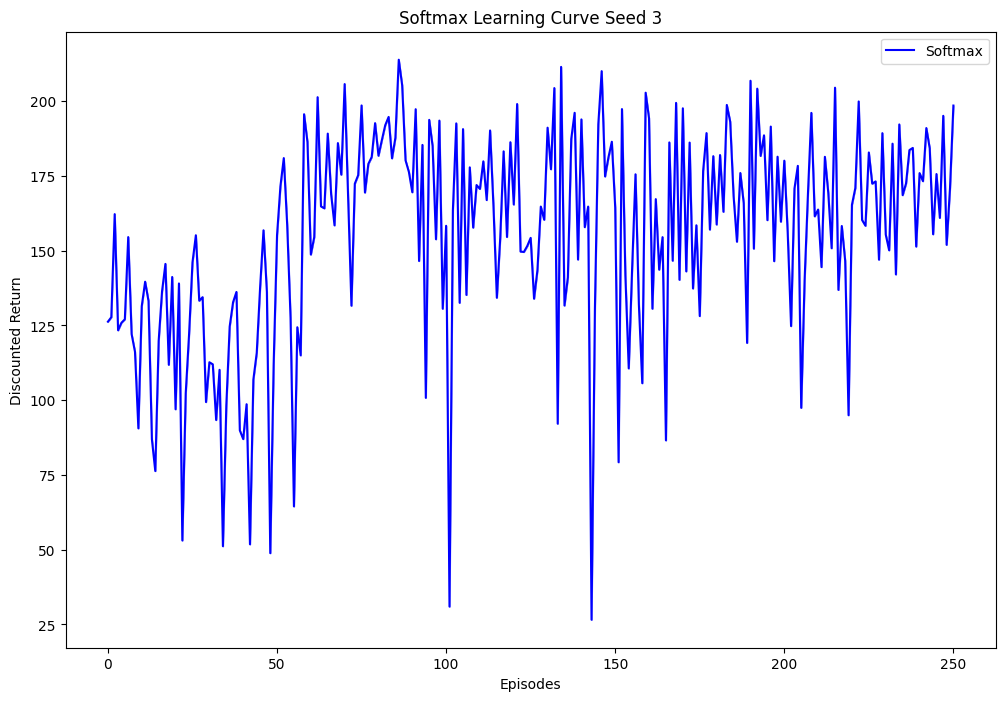

In [19]:
sm3 = np.load("data/mario_dqn_softmax_9012_returns.npy")
softmax_returns = np.array([sm3])

plot_curves(
    [softmax_returns],
    ['Softmax'],
    ['b'],
    'Discounted Return',
    'Softmax Learning Curve Seed 3'
)

# Agent 3: DQN + Heuristic

In [ ]:
class DQNAgent(object):
    # initialize the agent
    def __init__(self,
                 params,
                 ):
        # save the parameters
        self.params = params

        # environment parameters
        self.action_dim = params['action_dim']
        self.obs_dim = params['observation_dim']

        # executable actions
        self.action_space = params['action_space']

        # create value network
        self.behavior_policy_net = DeepQNet(input_shape=(4, 84, 84), n_actions=params['action_dim'])

        # create target network
        self.target_policy_net   = DeepQNet(input_shape=(4, 84, 84), n_actions=params['action_dim'])

        # initialize target network with behavior network
        self.behavior_policy_net.apply(customized_weights_init)
        self.target_policy_net.load_state_dict(self.behavior_policy_net.state_dict())

        # send the agent to a specific device: cpu or gpu
        self.device = torch.device("cuda")
        self.behavior_policy_net.to(self.device)
        self.target_policy_net.to(self.device)

        # optimizer
        self.optimizer = torch.optim.Adam(self.behavior_policy_net.parameters(), lr=params['learning_rate'])

    # get action
    def get_action(self, obs, eps):
        if np.random.random() < eps:  
            better_a = [1, 2, 3, 4]
            worse_a = [0, 5, 6]
        
            if np.random.random() < 0.8:
                action = np.random.choice(better_a)
            else:
                action = np.random.choice(worse_a)
            return action
        else:  
            obs = self._arr_to_tensor(obs).squeeze(-1).unsqueeze(0) 
            with torch.no_grad():
                q_values = self.behavior_policy_net(obs)
                action = q_values.max(dim=1)[1].item()
            return self.action_space[int(action)]

    # update behavior policy
    def update_behavior_policy(self, batch_data):
        # convert batch data to tensor and put them on device
        batch_data_tensor = self._batch_to_tensor(batch_data)

        # get the transition data
        obs_tensor = batch_data_tensor['obs']
        actions_tensor = batch_data_tensor['action']
        next_obs_tensor = batch_data_tensor['next_obs']
        rewards_tensor = batch_data_tensor['reward']
        dones_tensor = batch_data_tensor['done']

        # compute the q value estimation using the behavior network
        q_val = self.behavior_policy_net(obs_tensor)
        q = q_val.gather(1, actions_tensor)

        # compute the TD target using the target network
        next_q = self.target_policy_net(next_obs_tensor)
        max_q =  next_q.max(dim=1)[0].view(-1, 1).detach() 
        target = rewards_tensor + self.params['gamma'] * (1 - dones_tensor) * max_q

        # compute the loss
        loss = nn.MSELoss()
        td_loss = loss(q, target)

        # minimize the loss
        self.optimizer.zero_grad()
        td_loss.backward()
        self.optimizer.step()

        return td_loss.item()

    # update update target policy
    def update_target_policy(self):
        # hard update
        self.target_policy_net = copy.deepcopy(self.behavior_policy_net)

    # auxiliary functions
    def _arr_to_tensor(self, arr):
        arr = np.array(arr)
        arr_tensor = torch.from_numpy(arr).float().to(self.device)
        return arr_tensor

    def _batch_to_tensor(self, batch_data):
        # store the tensor
        batch_data_tensor = {'obs': [], 'action': [], 'reward': [], 'next_obs': [], 'done': []}
        # get the numpy arrays
        obs_arr, action_arr, reward_arr, next_obs_arr, done_arr = batch_data
        # convert to tensors
        batch_data_tensor['obs'] = torch.tensor(obs_arr, dtype=torch.float32).squeeze(-1).to(self.device)
        batch_data_tensor['action'] = torch.tensor(action_arr).long().view(-1, 1).to(self.device)
        batch_data_tensor['reward'] = torch.tensor(reward_arr, dtype=torch.float32).view(-1, 1).to(self.device)
        batch_data_tensor['next_obs'] = torch.tensor(next_obs_arr, dtype=torch.float32).squeeze(-1).to(self.device)
        batch_data_tensor['done'] = torch.tensor(done_arr, dtype=torch.float32).view(-1, 1).to(self.device)

        return batch_data_tensor


In [23]:
def train_dqn_agent(env, params):
    # create the DQN agent
    my_agent = DQNAgent(params)

    # create the epsilon-greedy schedule
    my_schedule = LinearSchedule(start_value=params['epsilon_start_value'],
                                 end_value=params['epsilon_end_value'],
                                 duration=params['epsilon_duration'])

    # create the replay buffer
    replay_buffer = ReplayBuffer(params['replay_buffer_size'])

    # training variables
    episode_t = 0
    rewards = []
    train_returns = []
    train_loss = []
    loss = 0

    # reset the environment
    obs, _ = env.reset()

    # start training
    pbar = trange(params['total_training_time_step'])
    last_best_return = 0
    for t in pbar:
        # scheduled epsilon at time step t
        eps_t = my_schedule.get_value(t)
        # get one epsilon-greedy action
        action = my_agent.get_action(obs, eps_t)

        # step in the environment
        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated  

        # add to the buffer
        replay_buffer.add(np.array(obs), action, reward, np.array(next_obs), done)
        rewards.append(reward)

        # check termination
        if done:
            # compute the return
            G = 0
            for r in reversed(rewards):
                G = r + params['gamma'] * G

            if G > last_best_return:
                torch.save(my_agent.behavior_policy_net.state_dict(), f"./{params['model_name']}.pt")

            # store the return
            train_returns.append(G)
            np.save(f"{params['model_name']}_returns.npy", np.array(train_returns))
            np.save(f"{params['model_name']}_loss.npy", np.array(train_loss))
            episode_idx = len(train_returns)

            # print the information
            pbar.set_description(
                f"Ep={episode_idx} | "
                f"G={np.mean(train_returns[-10:]) if train_returns else 0:.2f} | "
                f"Eps={eps_t}"
            )

            # reset the environment
            episode_t, rewards = 0, []
            obs, _ = env.reset()
        else:
            # increment
            obs = next_obs
            episode_t += 1

        if t > params['start_training_step']:
            # update the behavior model
            if not np.mod(t, params['freq_update_behavior_policy']):
                batch = replay_buffer.sample_batch(params['batch_size'])
                loss = my_agent.update_behavior_policy(batch)
                train_loss.append(loss)


            # update the target model
            if not np.mod(t, params['freq_update_target_policy']):
                my_agent.update_target_policy()

    # save the results
    return train_returns, train_loss

In [32]:
if __name__ == '__main__':
    # set the random seed
    np.random.seed(1234)
    random.seed(1234)
    torch.manual_seed(1234)

    # create environment
    my_env = make_env()

    # create training parameters
    train_parameters = {
        'observation_dim': (4, 84, 84),
        'action_dim': my_env.action_space.n,
        'action_space': list(range(my_env.action_space.n)),
        'gamma': 0.99,

        'total_training_time_step': 2_000_000,

        'epsilon_start_value': 1.0,
        'epsilon_end_value': 0.01,
        'epsilon_duration': 1_000_000,

        'replay_buffer_size': 100_000,
        'start_training_step': 10_000,
        'freq_update_behavior_policy': 4,
        'freq_update_target_policy': 2000,

        'batch_size': 64,
        'learning_rate': 1e-4,

        'model_name': "mario_dqn_heuristic_1234"
    }

    # create experiment
    train_returns, train_loss = train_dqn_agent(my_env, train_parameters)

  0%|          | 0/2000000 [00:00<?, ?it/s]

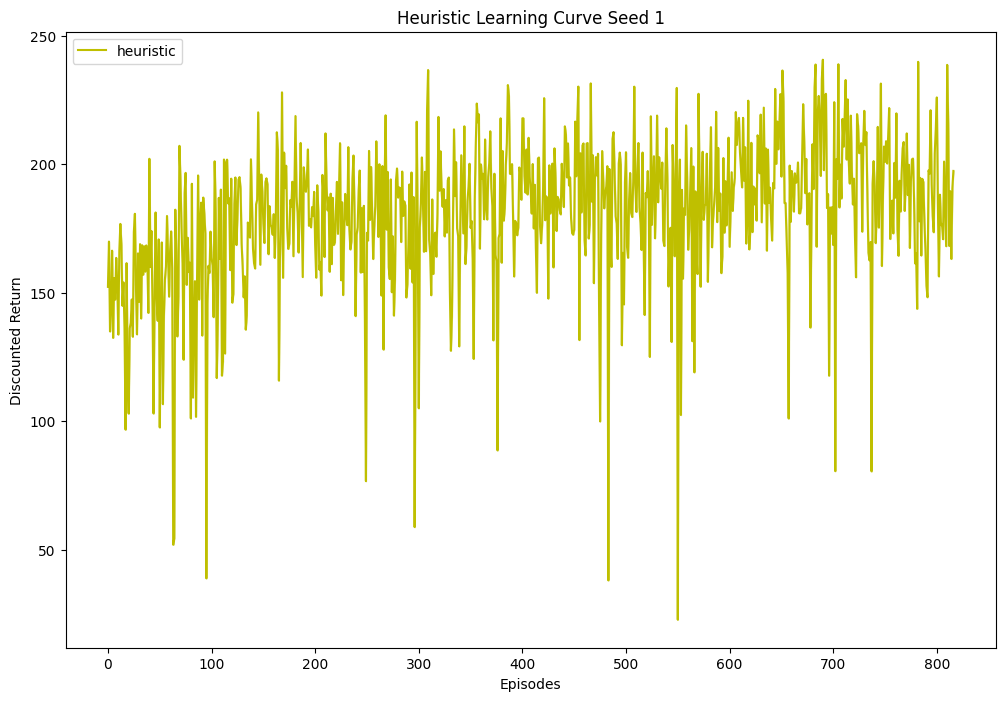

In [24]:
hr1 = np.load("data/mario_dqn_heuristic_1234_returns.npy")
heuristic_returns = np.array([hr1])

plot_curves(
    [heuristic_returns],
    ['heuristic'],
    ['y'],
    'Discounted Return',
    'Heuristic Learning Curve Seed 1'
)

In [34]:
if __name__ == '__main__':
    # set the random seed
    np.random.seed(5678)
    random.seed(5678)
    torch.manual_seed(5678)

    # create environment
    my_env = make_env()

    # create training parameters
    train_parameters = {
        'observation_dim': (4, 84, 84),
        'action_dim': my_env.action_space.n,
        'action_space': list(range(my_env.action_space.n)),
        'gamma': 0.99,

        'total_training_time_step': 2_000_000,

        'epsilon_start_value': 1.0,
        'epsilon_end_value': 0.01,
        'epsilon_duration': 1_000_000,

        'replay_buffer_size': 100_000,
        'start_training_step': 10_000,
        'freq_update_behavior_policy': 4,
        'freq_update_target_policy': 2000,

        'batch_size': 64,
        'learning_rate': 1e-4,

        'model_name': "mario_dqn_heuristic_5678"
    }

    # create experiment
    train_returns, train_loss = train_dqn_agent(my_env, train_parameters)

  0%|          | 0/2000000 [00:00<?, ?it/s]

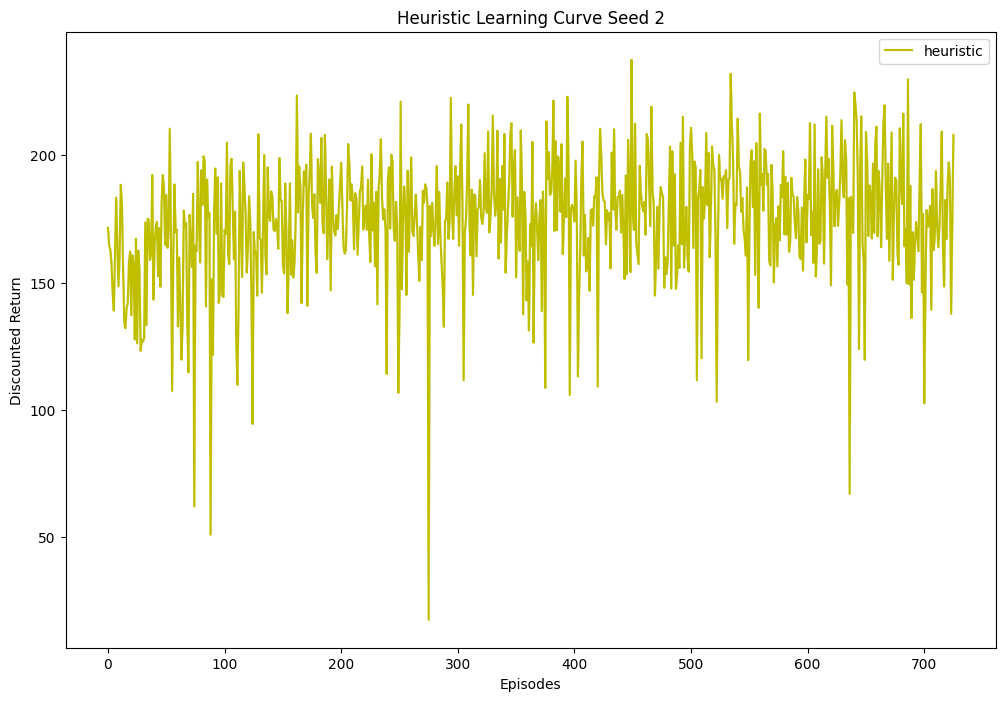

In [25]:
hr2 = np.load("data/mario_dqn_heuristic_5678_returns.npy")
heuristic_returns = np.array([hr2])

plot_curves(
    [heuristic_returns],
    ['heuristic'],
    ['y'],
    'Discounted Return',
    'Heuristic Learning Curve Seed 2'
)

In [35]:
if __name__ == '__main__':
    # set the random seed
    np.random.seed(9012)
    random.seed(9012)
    torch.manual_seed(9012)

    # create environment
    my_env = make_env()

    # create training parameters
    train_parameters = {
        'observation_dim': (4, 84, 84),
        'action_dim': my_env.action_space.n,
        'action_space': list(range(my_env.action_space.n)),
        'gamma': 0.99,

        'total_training_time_step': 2_000_000,

        'epsilon_start_value': 1.0,
        'epsilon_end_value': 0.01,
        'epsilon_duration': 1_000_000,

        'replay_buffer_size': 100_000,
        'start_training_step': 10_000,
        'freq_update_behavior_policy': 4,
        'freq_update_target_policy': 2000,

        'batch_size': 64,
        'learning_rate': 1e-4,

        'model_name': "mario_dqn_heuristic_9012"
    }

    # create experiment
    train_returns, train_loss = train_dqn_agent(my_env, train_parameters)

  0%|          | 0/2000000 [00:00<?, ?it/s]

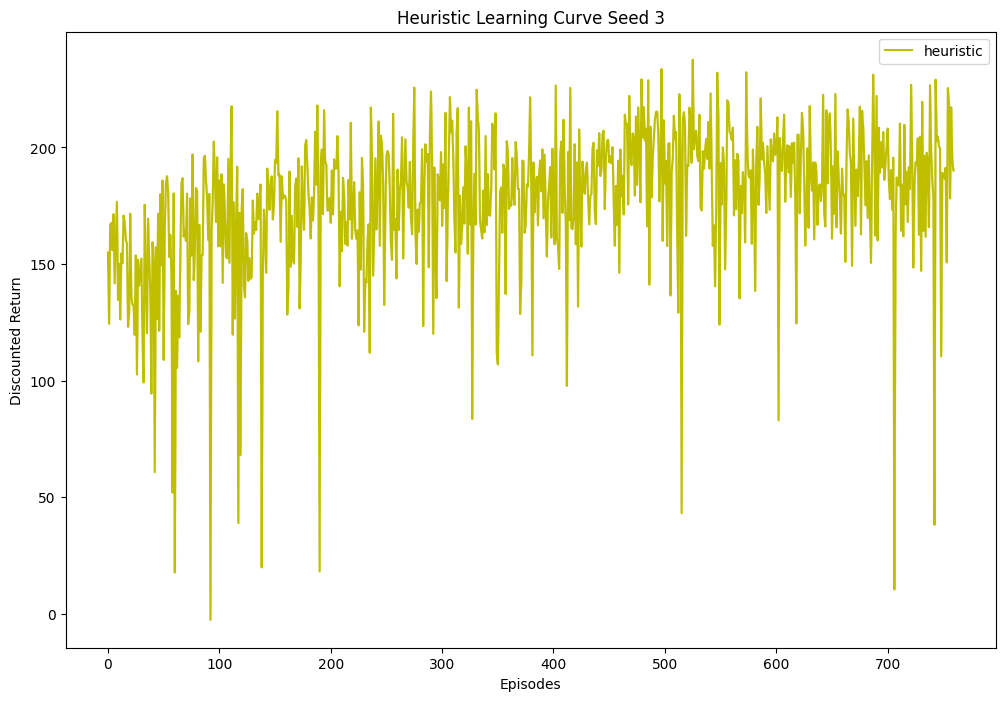

In [26]:
hr3 = np.load("data/mario_dqn_heuristic_9012_returns.npy")
heuristic_returns = np.array([hr3])

plot_curves(
    [heuristic_returns],
    ['heuristic'],
    ['y'],
    'Discounted Return',
    'Heuristic Learning Curve Seed 3'
)

# Agent 4: DQN + Noisy Networks

In [ ]:
# noisy networks implementation
class Nosiy_Linear(nn.Module):
    def __init__(self, dim_in, dim_out):
        super().__init__()
        self.weights = nn.Parameter(torch.rand((dim_in, dim_out)))
        self.bias = nn.Parameter(torch.rand(dim_out))
        self.sigma_weights = nn.Parameter(torch.full((dim_in, dim_out), 0.1))
        self.sigma_bias = nn.Parameter(torch.full((dim_out,), 0.1))

    def forward(self, X):
        if self.training:
            noise_weights = torch.randn_like(self.weights)
            noise_bias = torch.randn_like(self.bias)
            weight = self.weights + self.sigma_weights * noise_weights
            bia = self.bias + self.sigma_bias * noise_bias  
            return X @ weight + bia

        return X@self.weights + self.bias

In [ ]:
class DeepQNet(nn.Module):
    def __init__(self, input_shape, n_actions):
        super(DeepQNet, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU()
        )
        conv_out_size = self._get_conv_out(input_shape)
        self.fc = nn.Sequential(
            # switch Linear to Noisy_Linear
            Nosiy_Linear(conv_out_size, 512),
            nn.ReLU(),
            Nosiy_Linear(512, n_actions)
        )

    def _get_conv_out(self, shape):
        o = self.conv(torch.zeros(1, *shape))
        return int(np.prod(o.size()))

    def forward(self, x):
        x = x.float() / 255.0
        conv_out = self.conv(x).view(x.size()[0], -1)
        return self.fc(conv_out)

In [38]:
class DQNAgent(object):
    # initialize the agent
    def __init__(self,
                 params,
                 ):
        # save the parameters
        self.params = params

        # environment parameters
        self.action_dim = params['action_dim']
        self.obs_dim = params['observation_dim']

        # executable actions
        self.action_space = params['action_space']

        # create value network
        self.behavior_policy_net = DeepQNet(input_shape=(4, 84, 84), n_actions=params['action_dim'])

        # create target network
        self.target_policy_net   = DeepQNet(input_shape=(4, 84, 84), n_actions=params['action_dim'])

        # initialize target network with behavior network
        #self.behavior_policy_net.apply(customized_weights_init)
        self.target_policy_net.load_state_dict(self.behavior_policy_net.state_dict())

        # send the agent to a specific device: cpu or gpu
        self.device = torch.device("cuda")
        self.behavior_policy_net.to(self.device)
        self.target_policy_net.to(self.device)

        # optimizer
        self.optimizer = torch.optim.Adam(self.behavior_policy_net.parameters(), lr=params['learning_rate'])

    # get action
    def get_action(self, obs):
        obs = self._arr_to_tensor(obs).squeeze(-1).unsqueeze(0) 
        with torch.no_grad():
            q_values = self.behavior_policy_net(obs)
            action = q_values.max(dim=1)[1].item()
        return self.action_space[int(action)]

    # update behavior policy
    def update_behavior_policy(self, batch_data):
        # convert batch data to tensor and put them on device
        batch_data_tensor = self._batch_to_tensor(batch_data)

        # get the transition data
        obs_tensor = batch_data_tensor['obs']
        actions_tensor = batch_data_tensor['action']
        next_obs_tensor = batch_data_tensor['next_obs']
        rewards_tensor = batch_data_tensor['reward']
        dones_tensor = batch_data_tensor['done']

        # compute the q value estimation using the behavior network
        q_val = self.behavior_policy_net(obs_tensor)
        q = q_val.gather(1, actions_tensor)

        # compute the TD target using the target network
        next_q = self.target_policy_net(next_obs_tensor)
        max_q =  next_q.max(dim=1)[0].view(-1, 1).detach() 
        target = rewards_tensor + self.params['gamma'] * (1 - dones_tensor) * max_q

        # compute the loss
        loss = nn.MSELoss()
        td_loss = loss(q, target)

        # minimize the loss
        self.optimizer.zero_grad()
        td_loss.backward()
        self.optimizer.step()

        return td_loss.item()

    # update update target policy
    def update_target_policy(self):
        # hard update
        self.target_policy_net = copy.deepcopy(self.behavior_policy_net)

    # auxiliary functions
    def _arr_to_tensor(self, arr):
        arr = np.array(arr)
        arr_tensor = torch.from_numpy(arr).float().to(self.device)
        return arr_tensor

    def _batch_to_tensor(self, batch_data):
        # store the tensor
        batch_data_tensor = {'obs': [], 'action': [], 'reward': [], 'next_obs': [], 'done': []}
        # get the numpy arrays
        obs_arr, action_arr, reward_arr, next_obs_arr, done_arr = batch_data
        # convert to tensors
        batch_data_tensor['obs'] = torch.tensor(obs_arr, dtype=torch.float32).squeeze(-1).to(self.device)
        batch_data_tensor['action'] = torch.tensor(action_arr).long().view(-1, 1).to(self.device)
        batch_data_tensor['reward'] = torch.tensor(reward_arr, dtype=torch.float32).view(-1, 1).to(self.device)
        batch_data_tensor['next_obs'] = torch.tensor(next_obs_arr, dtype=torch.float32).squeeze(-1).to(self.device)
        batch_data_tensor['done'] = torch.tensor(done_arr, dtype=torch.float32).view(-1, 1).to(self.device)

        return batch_data_tensor

In [39]:
def train_dqn_agent(env, params):
    # create the DQN agent
    my_agent = DQNAgent(params)

    # create the epsilon-greedy schedule
    my_schedule = LinearSchedule(start_value=params['epsilon_start_value'],
                                 end_value=params['epsilon_end_value'],
                                 duration=params['epsilon_duration'])

    # create the replay buffer
    replay_buffer = ReplayBuffer(params['replay_buffer_size'])

    # training variables
    episode_t = 0
    rewards = []
    train_returns = []
    train_loss = []
    loss = 0

    # reset the environment
    obs, _ = env.reset()

    # start training
    pbar = trange(params['total_training_time_step'])
    last_best_return = 0
    for t in pbar:
        # scheduled epsilon at time step t
        eps_t = my_schedule.get_value(t)
        # get one epsilon-greedy action
        action = my_agent.get_action(obs)

        # step in the environment
        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated  

        # add to the buffer
        replay_buffer.add(np.array(obs), action, reward, np.array(next_obs), done)
        rewards.append(reward)

        # check termination
        if done:
            # compute the return
            G = 0
            for r in reversed(rewards):
                G = r + params['gamma'] * G

            if G > last_best_return:
                torch.save(my_agent.behavior_policy_net.state_dict(), f"./{params['model_name']}.pt")

            # store the return
            train_returns.append(G)
            np.save(f"{params['model_name']}_returns.npy", np.array(train_returns))
            np.save(f"{params['model_name']}_loss.npy", np.array(train_loss))
            episode_idx = len(train_returns)

            # print the information
            pbar.set_description(
                f"Ep={episode_idx} | "
                f"G={np.mean(train_returns[-10:]) if train_returns else 0:.2f} | "
                f"Eps={eps_t}"
            )

            # reset the environment
            episode_t, rewards = 0, []
            obs, _ = env.reset()
        else:
            # increment
            obs = next_obs
            episode_t += 1

        if t > params['start_training_step']:
            # update the behavior model
            if not np.mod(t, params['freq_update_behavior_policy']):
                batch = replay_buffer.sample_batch(params['batch_size'])
                loss = my_agent.update_behavior_policy(batch)
                train_loss.append(loss)


            # update the target model
            if not np.mod(t, params['freq_update_target_policy']):
                my_agent.update_target_policy()

    # save the results
    return train_returns, train_loss

In [42]:
if __name__ == '__main__':
    # set the random seed
    np.random.seed(1234)
    random.seed(1234)
    torch.manual_seed(1234)

    # create environment
    my_env = make_env()

    # create training parameters
    train_parameters = {
        'observation_dim': (4, 84, 84),
        'action_dim': my_env.action_space.n,
        'action_space': list(range(my_env.action_space.n)),
        'gamma': 0.99,

        'total_training_time_step': 2_000_000,

        'epsilon_start_value': 0,
        'epsilon_end_value': 0,
        'epsilon_duration': 1,

        'replay_buffer_size': 100_000,
        'start_training_step': 10_000,
        'freq_update_behavior_policy': 4,
        'freq_update_target_policy': 2000,

        'batch_size': 64,
        'learning_rate': 1e-4,

        'model_name': "mario_dqn_noisy_1234"
    }

    # create experiment
    train_returns, train_loss = train_dqn_agent(my_env, train_parameters)

  0%|          | 0/2000000 [00:00<?, ?it/s]

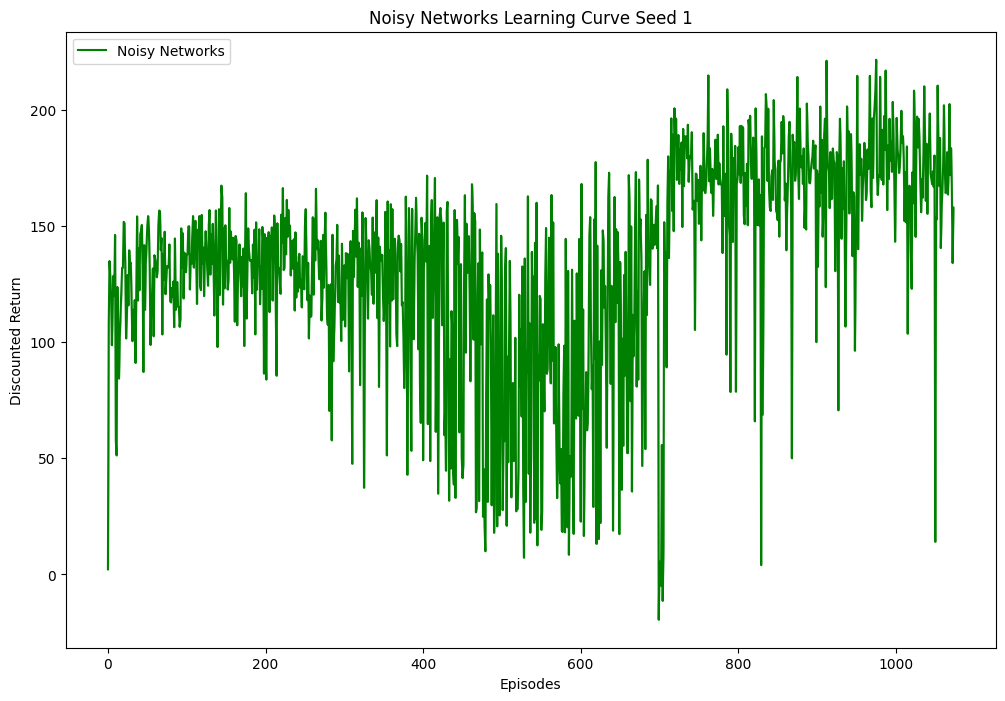

In [28]:
nn1 = np.load("data/mario_dqn_noisy_1234_returns.npy")
noisy_returns = np.array([nn1])

plot_curves(
    [noisy_returns],
    ['Noisy Networks'],
    ['g'],
    'Discounted Return',
    'Noisy Networks Learning Curve Seed 1'
)

In [45]:
if __name__ == '__main__':
    # set the random seed
    np.random.seed(5678)
    random.seed(5678)
    torch.manual_seed(5678)

    # create environment
    my_env = make_env()

    # create training parameters
    train_parameters = {
        'observation_dim': (4, 84, 84),
        'action_dim': my_env.action_space.n,
        'action_space': list(range(my_env.action_space.n)),
        'gamma': 0.99,

        'total_training_time_step': 2_000_000,

        'epsilon_start_value': 0,
        'epsilon_end_value': 0,
        'epsilon_duration': 1,

        'replay_buffer_size': 100_000,
        'start_training_step': 10_000,
        'freq_update_behavior_policy': 4,
        'freq_update_target_policy': 2000,

        'batch_size': 64,
        'learning_rate': 1e-4,

        'model_name': "mario_dqn_noisy_5678"
    }

    # create experiment
    train_returns, train_loss = train_dqn_agent(my_env, train_parameters)

  0%|          | 0/2000000 [00:00<?, ?it/s]

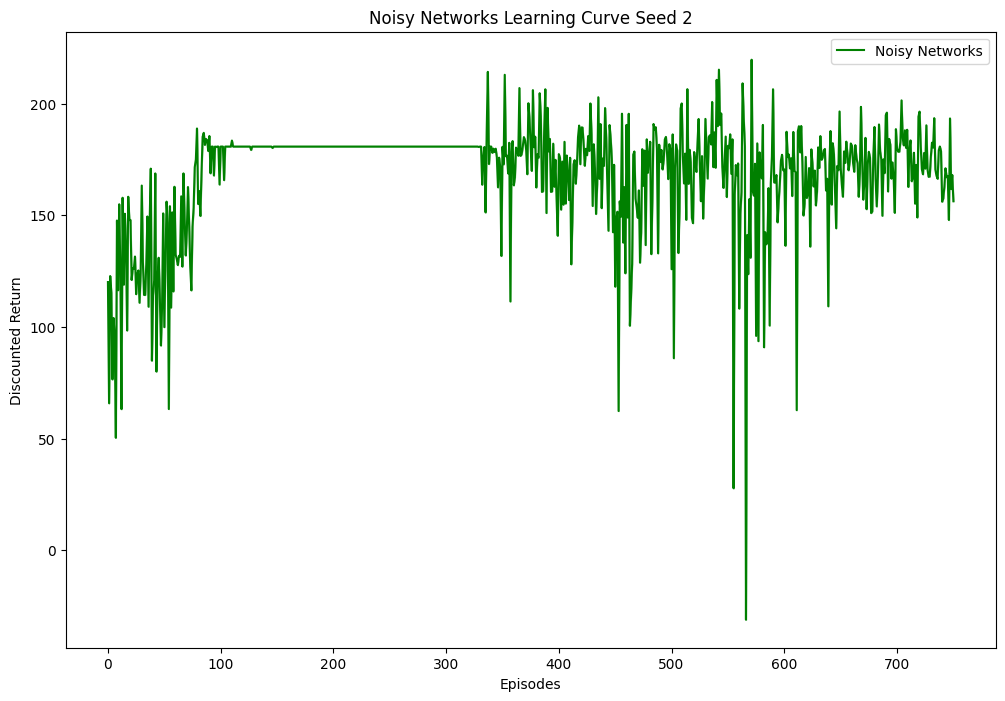

In [29]:
nn2 = np.load("data/mario_dqn_noisy_5678_returns.npy")
noisy_returns = np.array([nn2])

plot_curves(
    [noisy_returns],
    ['Noisy Networks'],
    ['g'],
    'Discounted Return',
    'Noisy Networks Learning Curve Seed 2'
)

In [50]:
if __name__ == '__main__':
    # set the random seed
    np.random.seed(9012)
    random.seed(9012)
    torch.manual_seed(9012)

    # create environment
    my_env = make_env()

    # create training parameters
    train_parameters = {
        'observation_dim': (4, 84, 84),
        'action_dim': my_env.action_space.n,
        'action_space': list(range(my_env.action_space.n)),
        'gamma': 0.99,

        'total_training_time_step': 2_000_000,

        'epsilon_start_value': 0,
        'epsilon_end_value': 0,
        'epsilon_duration': 1,

        'replay_buffer_size': 100_000,
        'start_training_step': 10_000,
        'freq_update_behavior_policy': 4,
        'freq_update_target_policy': 2000,

        'batch_size': 64,
        'learning_rate': 1e-4,

        'model_name': "mario_dqn_noisy_9012"
    }

    # create experiment
    train_returns, train_loss = train_dqn_agent(my_env, train_parameters)

  0%|          | 0/2000000 [00:00<?, ?it/s]

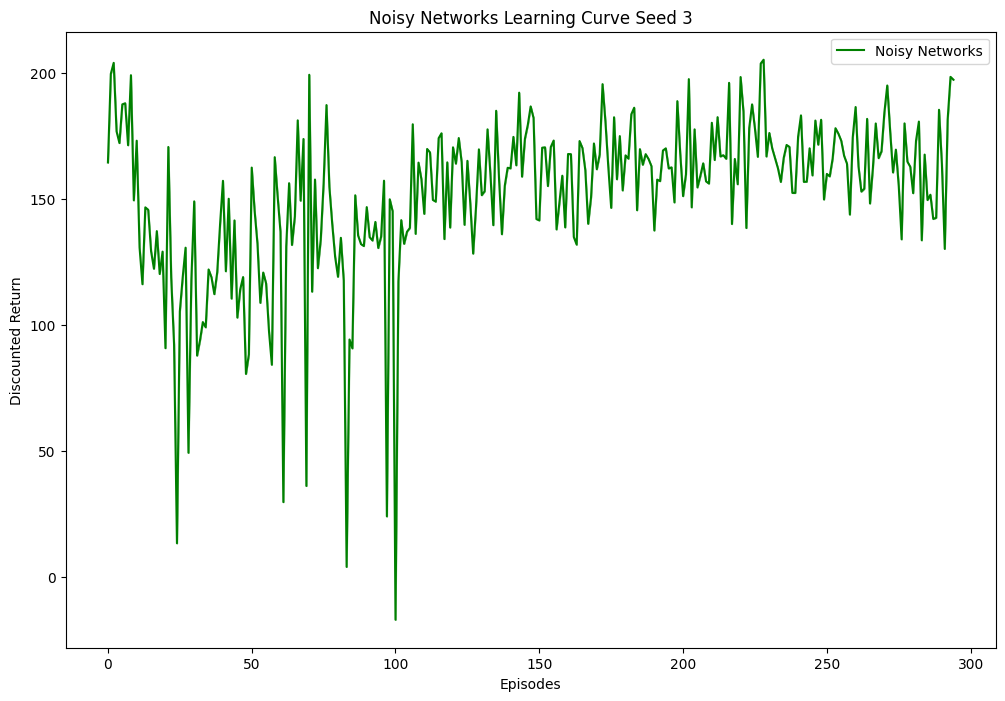

In [30]:
nn3 = np.load("data/mario_dqn_noisy_9012_returns.npy")
noisy_returns = np.array([nn3])

plot_curves(
    [noisy_returns],
    ['Noisy Networks'],
    ['g'],
    'Discounted Return',
    'Noisy Networks Learning Curve Seed 3'
)

# Plot All Agents Together

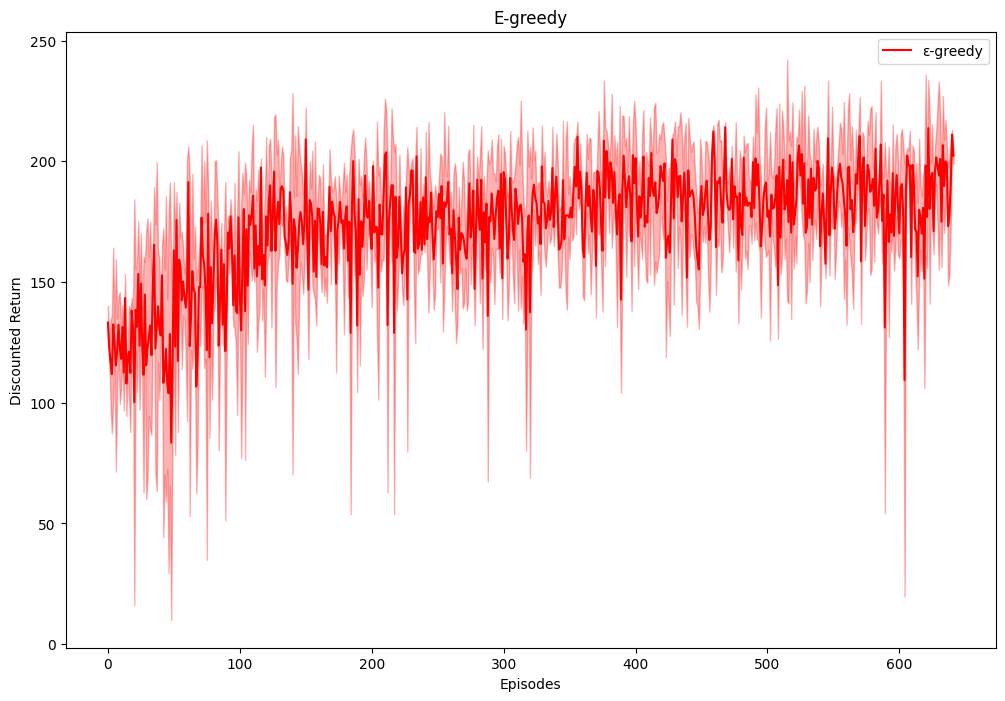

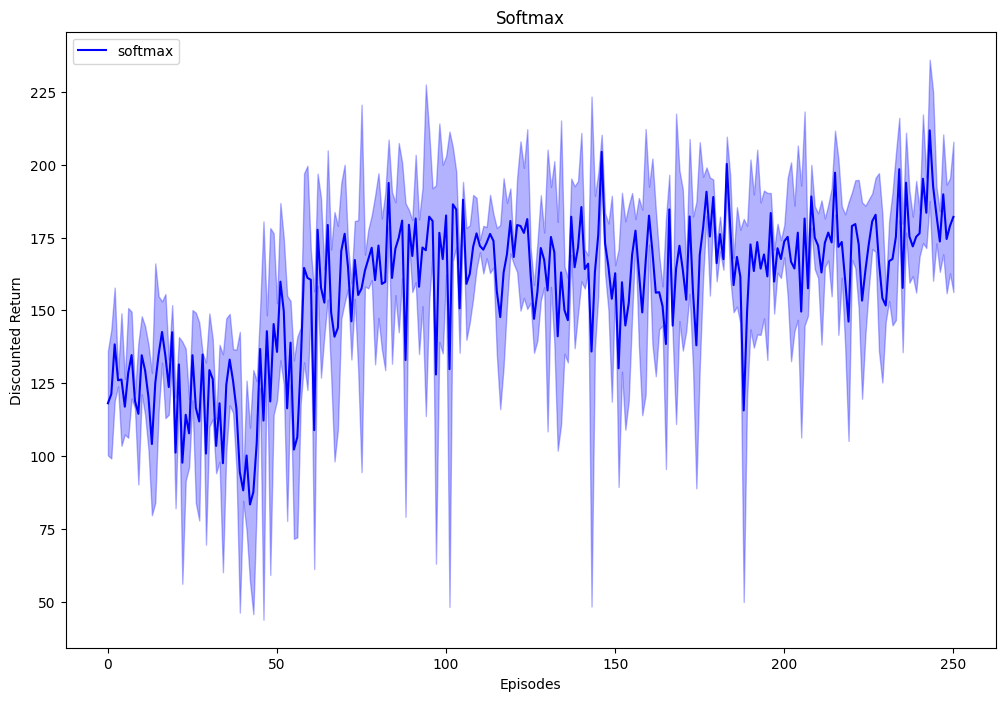

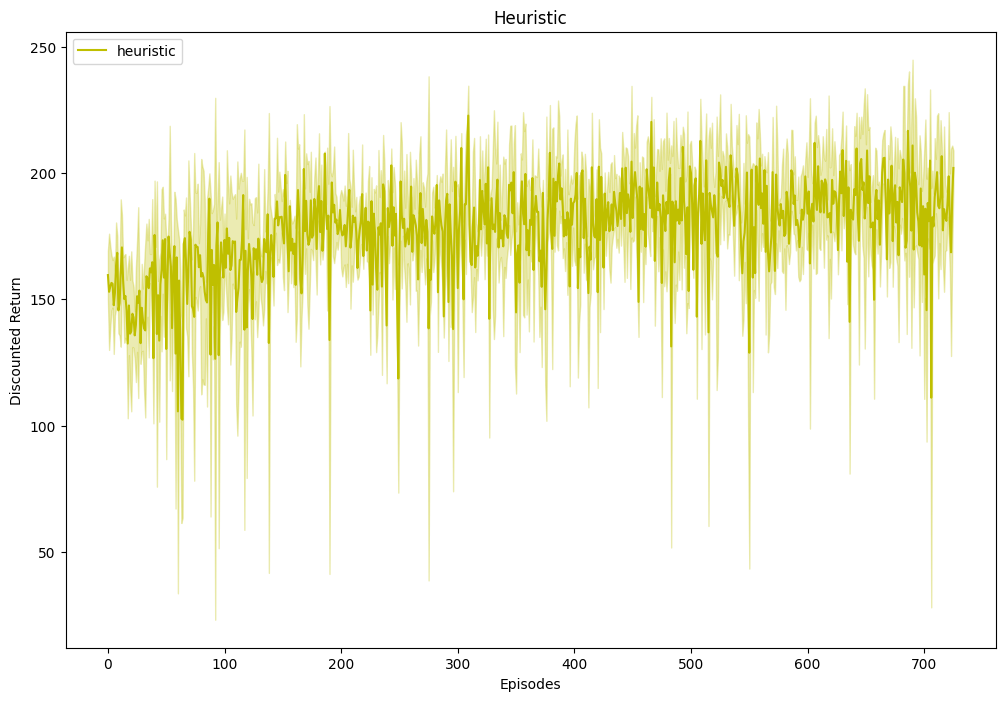

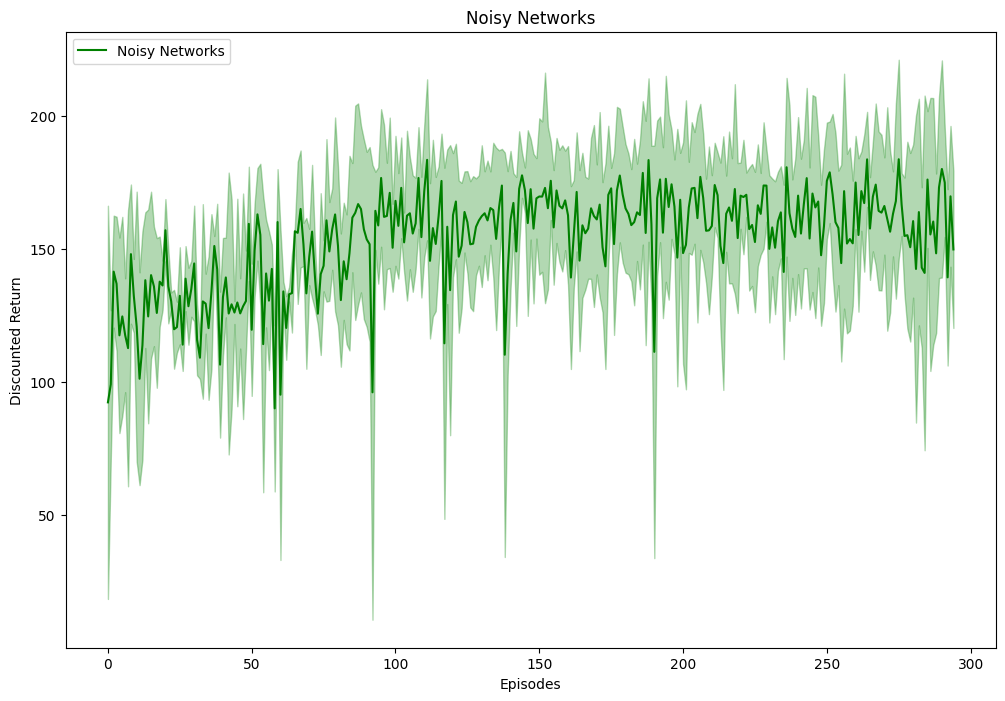

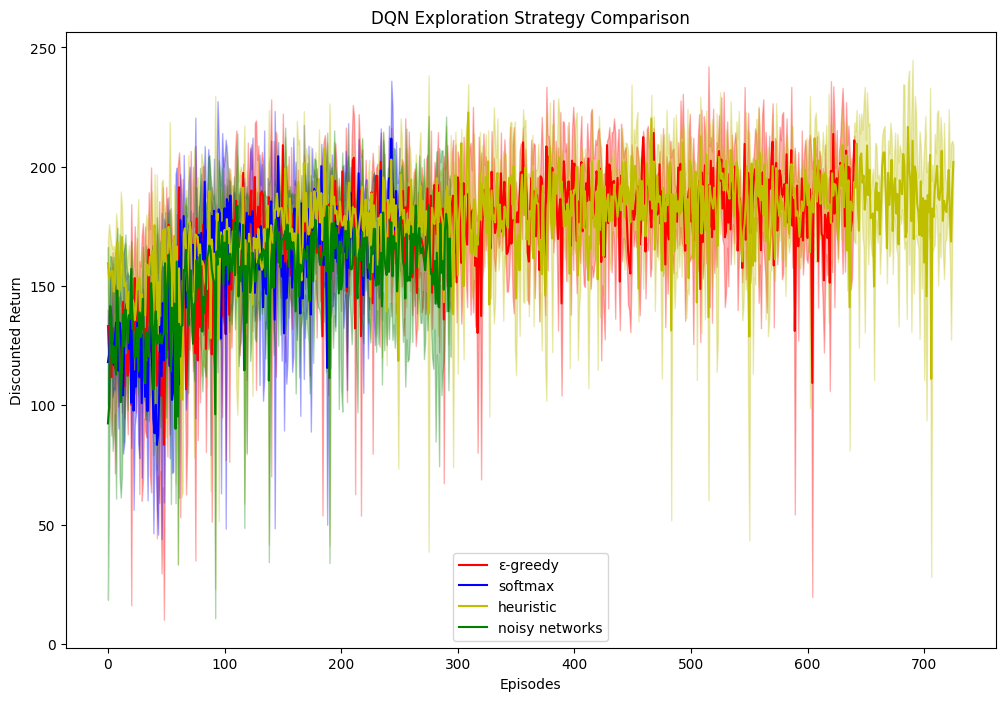

In [32]:
eg_min = min(len(eg1), len(eg2), len(eg3))
sm_min = min(len(sm1), len(sm2), len(sm3))
hr_min = min(len(hr1), len(hr2), len(hr3))
nn_min = min(len(nn1), len(nn2), len(nn3))

egreedy_returns = np.array([eg1[:eg_min], eg2[:eg_min], eg3[:eg_min]])
softmax_returns = np.array([sm1[:sm_min], sm2[:sm_min], sm3[:sm_min]])
heuristic_returns = np.array([hr1[:hr_min], hr2[:hr_min], hr3[:hr_min]])
noisy_returns = np.array([nn1[:nn_min], nn2[:nn_min], hr3[:nn_min]])

plot_curves(
    [egreedy_returns],
    ['ε-greedy'],
    ['r'],
    'Discounted Return',
    'E-greedy'
)

plot_curves(
    [softmax_returns],
    ['softmax'],
    ['b'],
    'Discounted Return',
    'Softmax'
)

plot_curves(
    [heuristic_returns],
    ['heuristic'],
    ['y'],
    'Discounted Return',
    'Heuristic'
)

plot_curves(
    [noisy_returns],
    ['Noisy Networks'],
    ['g'],
    'Discounted Return',
    'Noisy Networks'
)

plot_curves(
    [egreedy_returns, softmax_returns, heuristic_returns, noisy_returns],
    ['ε-greedy', 'softmax', 'heuristic', 'noisy networks'],
    ['r', 'b', 'y', 'g'],
    'Discounted Return',
    'DQN Exploration Strategy Comparison'
)

# Calculate average returns

In [ ]:

print("E-greedy seed 1:" , np.mean(eg1))
print("E-greedy seed 2:", np.mean(eg2))
print("E-grredy seed 3:", np.mean(eg3))
print()
print("Average Returns of E-greedy:")
print((np.mean(eg1) + np.mean(eg2) + np.mean(eg3))/3)

print()
print()

print("Softmax seed 1:" , np.mean(sm1))
print("Softmax seed 2:", np.mean(sm2))
print("Softmax seed 3:", np.mean(sm3))
print()
print("Average Returns of Softmax:")
print((np.mean(sm1) + np.mean(sm2) + np.mean(sm3))/3)


print()
print()

print("Heurisitc seed 1:" , np.mean(hr1))
print("Heuristic seed 2:", np.mean(hr2))
print("Heuristic seed 3:", np.mean(hr3))
print()
print("Average Returns of Hueristic:")
print((np.mean(hr1) + np.mean(hr2) + np.mean(hr3))/3)


print()
print()

print("NoisyNet seed 1:", np.mean(nn1))
print("NoisyNet seed 2:", np.mean(nn2))
print("NoisyNet seed 3:", np.mean(nn3))
print()
print("Average Returns of NoisyNet:")
print((np.mean(nn1) + np.mean(nn2) + np.mean(nn3))/3)

E-greedy seed 1: 173.71898549683553
E-greedy seed 2: 174.57912080233254
E-grredy seed 3: 173.53629045091347

Average Returns of E-greedy:
173.94479891669383


Softmax seed 1: 170.38845146846867
Softmax seed 2: 166.15143841255647
Softmax seed 3: 155.21028237284244

Average Returns of Softmax:
163.91672408462253


Heurisitc seed 1: 180.5767340055268
Heuristic seed 2: 174.7875236808089
Heuristic seed 3: 177.54430760165224

Average Returns of Hueristic:
177.6361884293293


NoisyNet seed 1: 133.49804059978493
NoisyNet seed 2: 168.76734721489117
NoisyNet seed 3: 151.37634532829264

Average Returns of NoisyNet:
151.21391104765624
